# Reproduction based on k-SII & more: Heskes et al. (2020)
This notebook reproduces **Figures** from the NeurIPS 2020 paper:

> Heskes, T., Bucur, I. G., Sijben, E., & Claassen, T. (2020).  
> *Causal Shapley Values: Exploiting Causal Knowledge to Explain Individual Predictions of Complex Models*  
> NeurIPS 2020

We compare **Marginal Shapley Values (MSV)** vs **Causal Shapley Values (CSV)** on the bike sharing dataset.

## Reference
- Paper: https://arxiv.org/abs/2011.01625
- Original R code: https://gitlab.science.ru.nl/gbucur/caushapley

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import shapiq
from shapiq import TabularExplainer
from shapiq.datasets import load_bike_sharing_daily, load_bike_sharing_daily_train_index

print(f"shapiq version: {shapiq.__version__}")


shapiq version: None


## 1. Load Bike Sharing Daily Data

The paper uses the UCI Bike Sharing Dataset (daily aggregates) with specific preprocessing:
- **trend**: Days since January 1, 2011
- **cosyear**: cos(2π × trend / 365) - cyclical season
- **sinyear**: sin(2π × trend / 365) - cyclical season
- **temp**: Unnormalized temperature (°C)
- **atemp**: Unnormalized feeling temperature (°C)
- **windspeed**: Unnormalized wind speed
- **hum**: Unnormalized humidity (%)

> **Source**: [`src/shapiq/datasets/_all.py`](../../src/shapiq/datasets/_all.py) → `load_bike_sharing_daily()` (Line 73-134)

In [2]:
x_data, y_data = load_bike_sharing_daily(preprocessed=True)
train_idx = load_bike_sharing_daily_train_index()

feature_names = ["trend", "cosyear", "sinyear", "temp", "atemp", "windspeed", "hum"]

all_idx = np.arange(len(x_data))
test_idx = np.array([i for i in all_idx if i not in train_idx])

print(f"Total: {len(x_data)}, Train: {len(train_idx)}, Test: {len(test_idx)}")
print(f"Features: {feature_names}")


Total: 731, Train: 587, Test: 144
Features: ['trend', 'cosyear', 'sinyear', 'temp', 'atemp', 'windspeed', 'hum']


In [3]:
# Prepare data with centering (as in original paper)
X_train = x_data.iloc[train_idx].values
y_train_nc = y_data.iloc[train_idx].values  # not centered
y_train_mean = y_train_nc.mean()
y_train = y_train_nc - y_train_mean  # centered

X_test = x_data.iloc[test_idx].values
y_test = y_data.iloc[test_idx].values - y_train_mean  # centered using train mean

print(f"y_train mean (φ₀): {y_train_mean:.2f}")

y_train mean (φ₀): 4505.03


### 1.1 Data Visualization: Bike Rentals Over Time

Before training the model, let's visualize the raw data to understand the relationship between time, temperature, and bike rentals. This reproduces the exploratory data analysis from the paper.!![alt text](bike_rental_plot_page-0001.jpg)

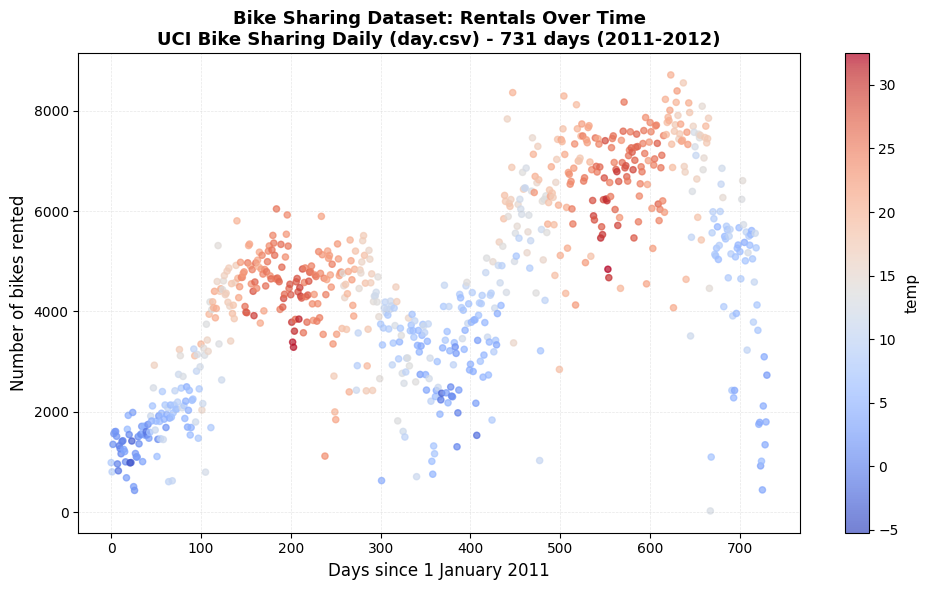

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

trend_values = x_data['trend'].values
temp_values = x_data['temp'].values
y_values = y_data.values

scatter = ax.scatter(trend_values, y_values, c=temp_values,
                     cmap='coolwarm', s=20, alpha=0.7)

ax.set_xlabel('Days since 1 January 2011', fontsize=12)
ax.set_ylabel('Number of bikes rented', fontsize=12)
ax.set_title('Bike Sharing Dataset: Rentals Over Time\n'
             'UCI Bike Sharing Daily (day.csv) - 731 days (2011-2012)', 
             fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('temp', fontsize=11)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


## 2. Train XGBoost Model

In [5]:
model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=1,
    verbosity=0
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"Test RMSE (centered): {rmse:.2f}")

Test RMSE (centered): 775.24


## 3. Define Causal Structure

From Section 6 of the paper:
- **Layer 1 (Root cause)**: `{trend}`
- **Layer 2 (Confounded)**: `{cosyear, sinyear}` - season affects weather
- **Layer 3 (Mutual interactions)**: `{temp, atemp, windspeed, hum}`

Confounding:
- Layer 1: No confounding (singleton)
- Layer 2: **Confounding = True** (common cause breaks dependencies on intervention)
- Layer 3: No confounding (mutual interactions preserved)

> **Note**: However, from a strict causal perspective, **treating season as a cause of weather (or as same-layer causal variables) may be a misattribution**. An alternative corrected causal structure is available in `paper_figure3_alternative_ordering.ipynb` in the same directory for comparison.

In [6]:
# Causal ordering (matching shapr R package)
ordering = [
    [0],           # Layer 1: trend (root)
    [1, 2],        # Layer 2: cosyear, sinyear (confounded)
    [3, 4, 5, 6],  # Layer 3: temp, atemp, windspeed, hum
]

# Confounding per component
confounding = [False, True, False]

print("Causal Structure:")
for i, layer in enumerate(ordering):
    layer_names = [feature_names[j] for j in layer]
    print(f"  Layer {i+1}: {layer_names} (confounding={confounding[i]})")

Causal Structure:
  Layer 1: ['trend'] (confounding=False)
  Layer 2: ['cosyear', 'sinyear'] (confounding=True)
  Layer 3: ['temp', 'atemp', 'windspeed', 'hum'] (confounding=False)


## 4. Create Explainers

- **Marginal**: Standard SHAP (assumes feature independence)
- **Causal**: Uses CausalImputer with copula sampling

### Important: This Notebook Uses k-SII (Not Pure Shapley Values)

The R code (`shapr`) computes **pure Shapley values** $\phi_i$ using exact KernelSHAP (enumerating all $2^7=128$ coalitions). 

This notebook uses `index="k-SII"` (max_order=2), which computes the **k-Shapley Interaction Index** — decomposing predictions into 1st-order main effects *and* 2nd-order interactions. The 1st-order k-SII values $I_{\{i\}}^{\text{k-SII}}$ are **not** the same as pure Shapley values:

$$\phi_i = I_{\{i\}}^{\text{k-SII}} + \frac{1}{2}\sum_{j \neq i} I_{\{i,j\}}^{\text{k-SII}}$$

k-SII "distributes" part of the attribution into pairwise interaction terms, so:
- **1st-order k-SII values are systematically smaller** in magnitude than pure SV
- The scatter/beeswarm plots show **the same qualitative patterns** as the paper, but with smaller magnitudes
- The **interaction network graphs** (Part II) provide additional insight not available from pure SV

#### Other Quantitative Differences from R
1. **Approximator**: R uses exact KernelSHAP (128 coalitions); shapiq uses KernelSHAPIQ (regression-based)
2. **XGBoost**: R vs Python implementations produce slightly different models
3. **Random seed**: `set.seed(2020)` in R ≠ `default_rng(2020)` in Python

These produce **quantitative** but not **qualitative** differences. The causal insight — that CSV shifts attribution from `temp` to `cosyear` — is preserved.

>  **For a faithful pure SV reproduction** of the paper's figures, see **`heskes_pure_reproduction.ipynb`** in the same directory.

In [7]:
RANDOM_STATE = 2020
SAMPLE_SIZE = 500

explainers = {}

# Marginal (Gaussian)
explainers['Marginal (Gaussian)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    sampling_method="gaussian",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# Marginal (Copula)
explainers['Marginal (Copula)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# Causal + Model (Gaussian)
explainers['Causal+ML (Gaussian)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="causal",
    ordering=ordering,
    confounding=confounding,
    sampling_method="gaussian",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# Causal + Model (Copula)
explainers['Causal+ML (Copula)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="causal",
    ordering=ordering,
    confounding=confounding,
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# Model-free causal (Y as final node)
explainers['Causal No-ML (Copula)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="no_ml_causal",
    y=y_train,
    ordering=ordering,
    confounding=confounding,
    sampling_method="copula",
    sample_size=SAMPLE_SIZE,
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

print(f"Explainers ready: {list(explainers.keys())}")


Explainers ready: ['Marginal (Gaussian)', 'Marginal (Copula)', 'Causal+ML (Gaussian)', 'Causal+ML (Copula)', 'Causal No-ML (Copula)']


## 5. Compute k-SII Values for All Test Samples

>  **Note**: This step computes **k-SII (max_order=2)** interaction values for all methods across all test samples. Expected runtime: **2-4 minutes** depending on your hardware.

In [8]:
budget = 2048
n_features = len(feature_names)

all_ksii = {}
all_sv = {}

for exp_name, explainer in explainers.items():
    print(f"\n{exp_name} ({len(X_test)} samples)...")
    ksii_list = []
    sv = np.zeros((len(X_test), n_features))

    for i in range(len(X_test)):
        result = explainer.explain(X_test[i:i+1], budget=budget)
        ksii_list.append(result)
        sv[i] = result.get_n_order_values(order=1)
        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{len(X_test)}")

    all_ksii[exp_name] = ksii_list
    all_sv[exp_name] = sv

print("\nDone.")



Marginal (Gaussian) (144 samples)...
  50/144
  100/144

Marginal (Copula) (144 samples)...
  50/144
  100/144

Causal+ML (Gaussian) (144 samples)...
  50/144
  100/144

Causal+ML (Copula) (144 samples)...
  50/144
  100/144

Causal No-ML (Copula) (144 samples)...
  50/144
  100/144

Done.


## 6. Scatter Plots: 2×2 Grid Comparison (k-SII 1st-Order)

> **Note**: These scatter plots use **k-SII 1st-order values** $I_{\{i\}}^{\text{k-SII}}$, which are systematically smaller in magnitude than pure Shapley values. The qualitative patterns (CSV shifts attribution from temp to cosyear) are preserved. For pure SV plots, see `heskes_pure_reproduction.ipynb`.

The original Figure 3 layout:
- **Top left**: MSV temp (x) vs MSV cosyear (y)
- **Top right**: CSV cosyear (x) vs MSV cosyear (y)
- **Bottom left**: MSV temp (x) vs CSV temp (y)
- **Bottom right**: CSV cosyear (x) vs CSV temp (y)

All colored by temperature (blue=cold, red=hot).

> For Figure 3 reproduction: use k-SII 1st-order values for Marginal (Gaussian) and Causal+ML (Gaussian). These are k-SII 1st-order I_{i}^{k-SII}, NOT pure SV φ_i. For pure SV reproduction, see heskes_pure_reproduction.ipynb

![alt text](scatter_plots_top_page-0001.jpg)![alt text](scatter_plots_bottom_page-0001.jpg)

In [9]:
sv_marginal = all_sv['Marginal (Gaussian)']
sv_causal = all_sv['Causal+ML (Gaussian)']

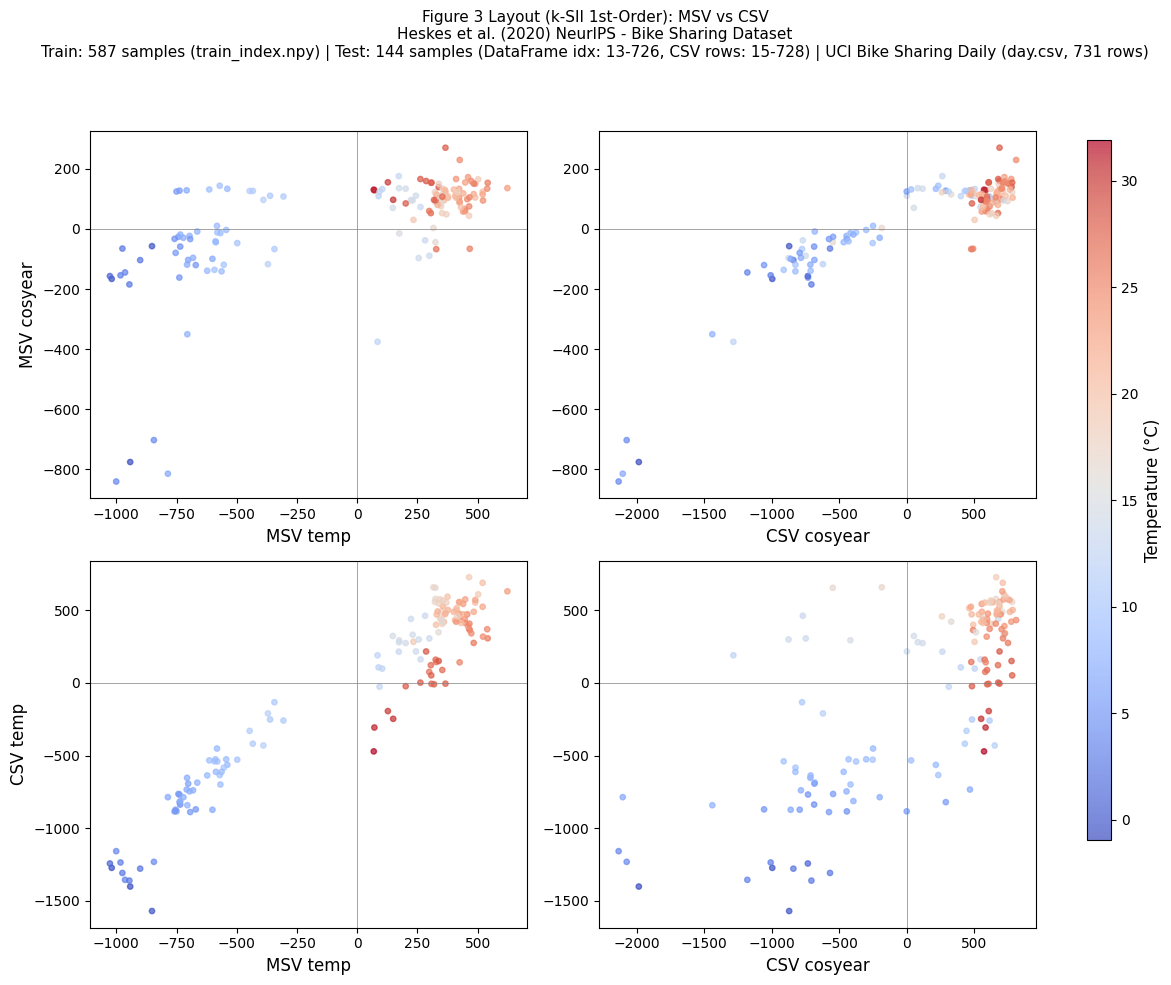

In [10]:
temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')

sv_marg_temp = sv_marginal[:, temp_idx]
sv_marg_cosyear = sv_marginal[:, cosyear_idx]
sv_caus_temp = sv_causal[:, temp_idx]
sv_caus_cosyear = sv_causal[:, cosyear_idx]

temp_values = X_test[:, temp_idx]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cmap = 'coolwarm'
point_size = 15

ax = axes[0, 0]
scatter = ax.scatter(sv_marg_temp, sv_marg_cosyear, c=temp_values,
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('MSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

ax = axes[0, 1]
ax.scatter(sv_caus_cosyear, sv_marg_cosyear, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

ax = axes[1, 0]
ax.scatter(sv_marg_temp, sv_caus_temp, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('MSV temp', fontsize=12)
ax.set_ylabel('CSV temp', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

ax = axes[1, 1]
scatter = ax.scatter(sv_caus_cosyear, sv_caus_temp, c=temp_values,
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('CSV cosyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)', fontsize=12)

test_csv_rows = test_idx + 2
plt.suptitle('Figure 3 Layout (k-SII 1st-Order): MSV vs CSV\n'
             'Heskes et al. (2020) NeurIPS - Bike Sharing Dataset\n'
             f'Train: {len(train_idx)} samples (train_index.npy) | '
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]}) | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=11)
plt.tight_layout(rect=[0, 0, 0.88, 0.94])
plt.show()


## 6.2. Beeswarm Comparison (All Methods)

![alt text](sina_plot_causal_page-0001.jpg)

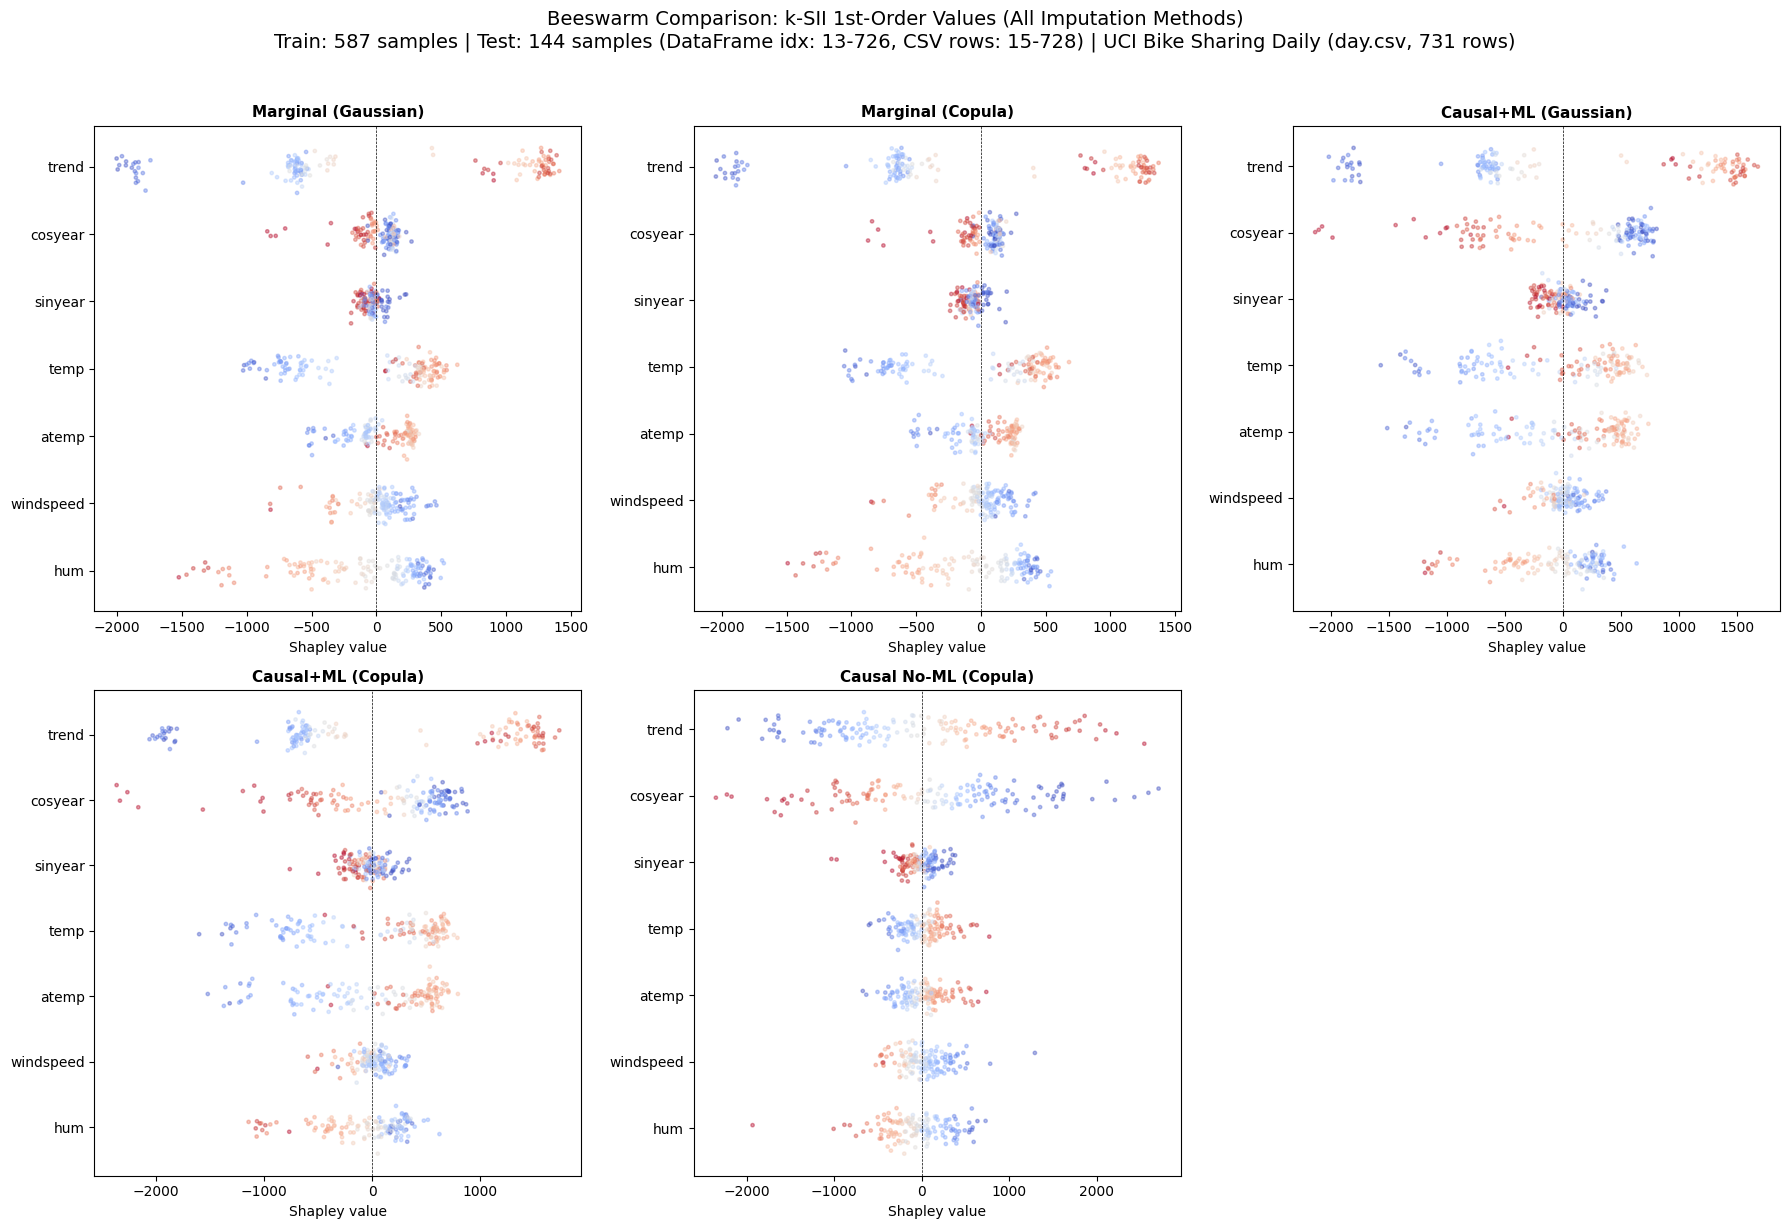

In [11]:
n_methods = len(all_sv)
n_cols = 3
n_rows = (n_methods + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

order = list(range(len(feature_names)))

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]

    for i, f_idx in enumerate(order):
        fv = X_test[:, f_idx]
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-10)

        y_jitter = np.random.normal(0, 0.12, len(sv)) + (len(feature_names) - 1 - i)
        ax.scatter(sv[:, f_idx], y_jitter, c=fv_norm, cmap='coolwarm',
                  alpha=0.4, s=6)

    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[order[len(feature_names) - 1 - i]]
                        for i in range(len(feature_names))])
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Shapley value')
    ax.set_title(exp_name, fontsize=11, fontweight='bold')

for ax_idx in range(n_methods, len(axes)):
    axes[ax_idx].set_visible(False)
test_csv_rows = test_idx + 2
plt.suptitle('Beeswarm Comparison: k-SII 1st-Order Values (All Imputation Methods)\n'
             f'Train: {len(train_idx)} samples | '
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]}) | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 9. Summary Statistics

> **Note**: The summary statistics comparison is inspired by the analysis approach in Heskes et al. (2020), where the authors compared feature attributions between MSV and CSV. Here we extend this comparison to all 6 imputation methods to provide a comprehensive understanding of how different modeling assumptions affect Shapley value attributions.

In [12]:
test_csv_rows = test_idx + 2

summary_df = pd.DataFrame(index=feature_names)
for exp_name, sv in all_sv.items():
    summary_df[exp_name] = np.abs(sv).mean(axis=0)

# Shorter column names for display
short_names = {
    'Marginal (Joint)': 'Marg(Joint)',
    'Marginal (Gaussian)': 'Marg(Gauss)',
    'Marginal (Copula)': 'Marg(Copula)',
    'Causal+ML (Gaussian)': 'Caus(Gauss)★',
    'Causal+ML (Copula)': 'Caus+ML(Copula)',
    'Causal No-ML (Copula)': 'NoML'
}
summary_df.columns = [short_names.get(c, c) for c in summary_df.columns]

print(summary_df.round(2).to_string())


           Marg(Gauss)  Marg(Copula)  Caus(Gauss)★  Caus+ML(Copula)    NoML
trend           997.37        997.01       1059.80          1080.66  897.86
cosyear         125.56        130.00        639.95           572.60  839.36
sinyear          61.60         85.39        111.66           124.66  147.06
temp            467.03        505.46        519.12           584.00  186.38
atemp           201.76        192.09        478.99           500.14  196.84
windspeed       156.56        147.37        116.42           120.76  197.18
hum             394.73        395.66        323.61           304.49  281.12


## 10. Two Similar Days Analysis

> **Note**: This analysis replicates the "two similar days" comparison from Heskes et al. (2020), where the authors demonstrated how MSV and CSV differ in explaining predictions for days with similar temperatures but different seasons. We extend this visualization to include all 6 imputation methods, allowing for a comprehensive comparison across different modeling assumptions.

Following the paper's analysis: compare two days with similar temperatures but different seasons.![alt text](bar_plots_page-0001.jpg)

October day 2012-10-09 (DataFrame idx 647, CSV row 649): temp=13.0°C, cosyear=0.14
December day 2012-12-03 (DataFrame idx 702, CSV row 704): temp=13.3°C, cosyear=0.89


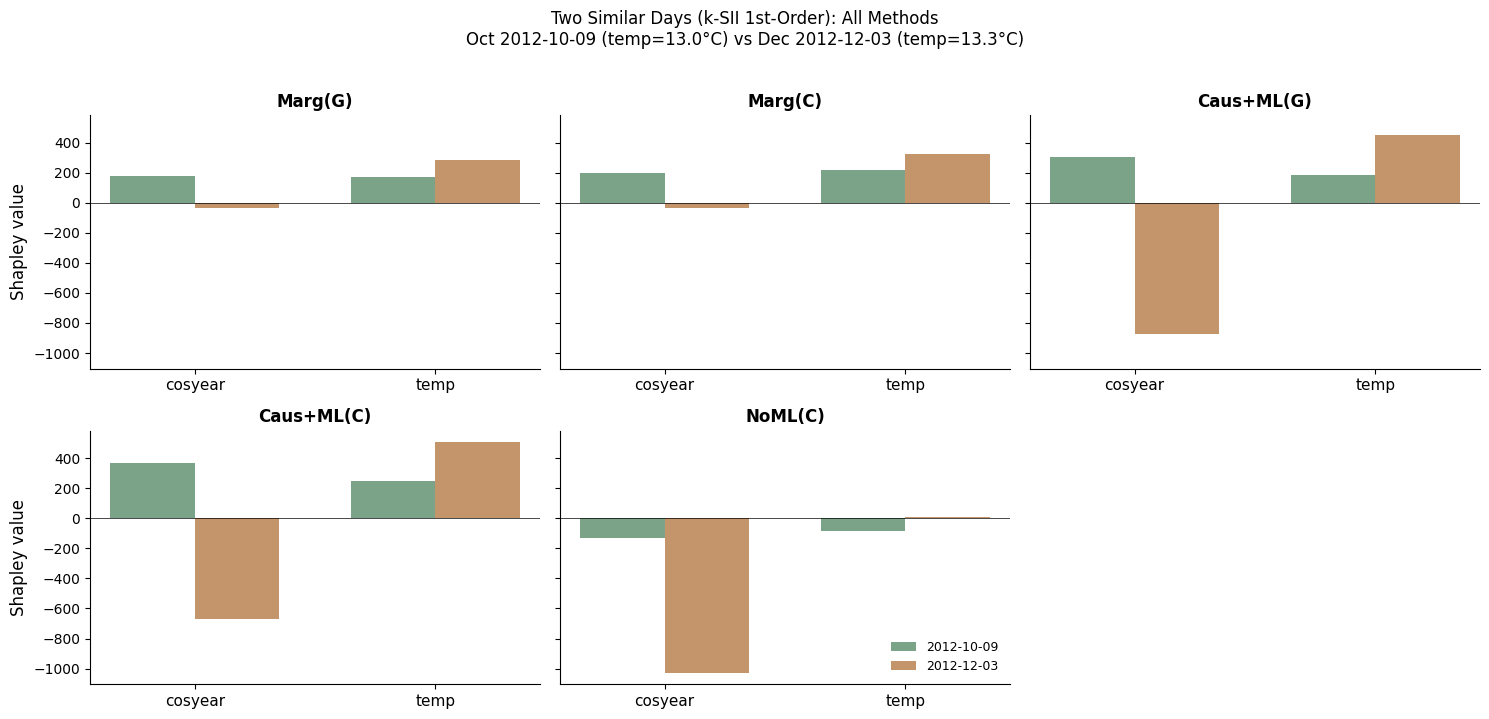

In [13]:
# match R code (bike_rental_illustration.R):
#   october <- which(bike$dteday == "2012-10-09")  → instant 648
#   december <- which(bike$dteday == "2012-12-03") → instant 703
# DataFrame index (0-based) = instant - 1

x_full, y_full = load_bike_sharing_daily(preprocessed=True)

october_idx = 647   # 2012-10-09 (instant=648): temp≈13.0°C, cosyear≈0.14
december_idx = 702  # 2012-12-03 (instant=703): temp≈13.3°C, cosyear≈0.89

october_csv_row = october_idx + 2
december_csv_row = december_idx + 2

print(f"October day 2012-10-09 (DataFrame idx {october_idx}, CSV row {october_csv_row}): "
      f"temp={x_full.loc[october_idx, 'temp']:.1f}°C, "
      f"cosyear={x_full.loc[october_idx, 'cosyear']:.2f}")
print(f"December day 2012-12-03 (DataFrame idx {december_idx}, CSV row {december_csv_row}): "
      f"temp={x_full.loc[december_idx, 'temp']:.1f}°C, "
      f"cosyear={x_full.loc[december_idx, 'cosyear']:.2f}")

days_x = x_full.loc[[october_idx, december_idx], feature_names].values

sv_days_all = {}
for exp_name, explainer in explainers.items():
    sv_days = []
    for x in days_x:
        result = explainer.explain(x.reshape(1, -1), budget=budget)
        sv_days.append(result.get_n_order_values(order=1))
    sv_days_all[exp_name] = np.array(sv_days)

method_names = list(explainers.keys())
short_names_title = [n.replace('Marginal', 'Marg').replace('Causal+ML', 'Caus+ML')
                     .replace('Causal No-ML', 'NoML').replace(' (Gaussian)', '(G)')
                     .replace(' (Copula)', '(C)') for n in method_names]
feat_labels = ['cosyear', 'temp']
feat_indices = [cosyear_idx, temp_idx]
date_labels = ['2012-10-09', '2012-12-03']
date_colors = ['#7BA388', '#C4956A']   # sage, terracotta

n_methods = len(method_names)
n_cols = min(n_methods, 3)
n_rows = (n_methods + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), sharey=True)
axes = np.array(axes).flatten()

bar_width = 0.35
x_pos = np.arange(len(feat_labels))

oct_temp = x_full.loc[october_idx, 'temp']
dec_temp = x_full.loc[december_idx, 'temp']

for ax_idx, m_name in enumerate(method_names):
    ax = axes[ax_idx]
    oct_vals = [sv_days_all[m_name][0, fi] for fi in feat_indices]
    dec_vals = [sv_days_all[m_name][1, fi] for fi in feat_indices]

    ax.bar(x_pos - bar_width / 2, oct_vals, bar_width,
           color=date_colors[0], label=date_labels[0])
    ax.bar(x_pos + bar_width / 2, dec_vals, bar_width,
           color=date_colors[1], label=date_labels[1])

    ax.set_xticks(x_pos)
    ax.set_xticklabels(feat_labels, fontsize=11)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(short_names_title[ax_idx], fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ax_idx % n_cols == 0:
        ax.set_ylabel('Shapley value', fontsize=12)

for ax_idx in range(n_methods, len(axes)):
    axes[ax_idx].set_visible(False)

axes[n_methods - 1].legend(loc='lower right', fontsize=9, frameon=False)

plt.suptitle('Two Similar Days (k-SII 1st-Order): All Methods\n'
             f'Oct 2012-10-09 (temp={oct_temp:.1f}°C) vs Dec 2012-12-03 (temp={dec_temp:.1f}°C)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---

# Part II: Comprehensive Imputer Comparison (Additional Analysis)

> **Note**: This section contains **additional exploratory analysis** beyond the paper reproduction. These visualizations provide deeper insights into the differences between all 6 imputation methods and are useful for understanding the behavior of various Shapley value computation approaches.

Now we compare all 6 imputation methods systematically to understand how different assumptions affect Shapley value attributions.

## 11. Feature Importance Comparison Across All Imputers

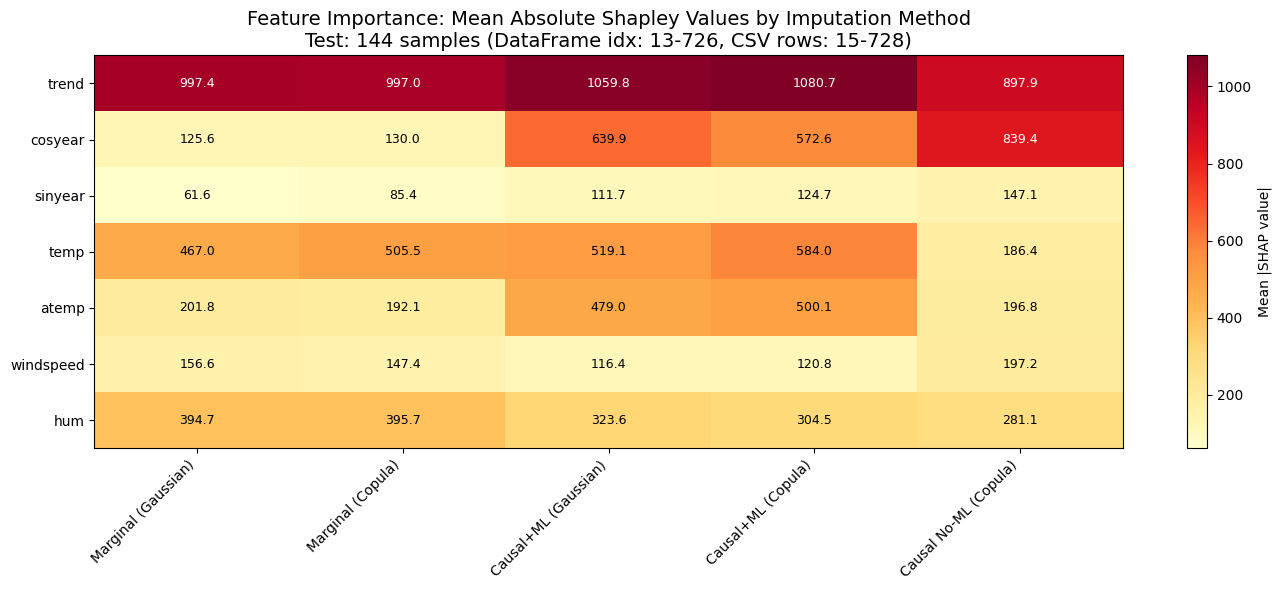

           Marginal (Gaussian)  Marginal (Copula)  Causal+ML (Gaussian)  Causal+ML (Copula)  Causal No-ML (Copula)
trend                   997.37             997.01               1059.80             1080.66                 897.86
cosyear                 125.56             130.00                639.95              572.60                 839.36
sinyear                  61.60              85.39                111.66              124.66                 147.06
temp                    467.03             505.46                519.12              584.00                 186.38
atemp                   201.76             192.09                478.99              500.14                 196.84
windspeed               156.56             147.37                116.42              120.76                 197.18
hum                     394.73             395.66                323.61              304.49                 281.12


In [14]:
importance_df = pd.DataFrame(index=feature_names)

for exp_name, sv in all_sv.items():
    importance_df[exp_name] = np.abs(sv).mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(importance_df.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(importance_df.columns)))
ax.set_xticklabels(importance_df.columns, rotation=45, ha='right')
ax.set_yticks(range(len(importance_df.index)))
ax.set_yticklabels(importance_df.index)

for i in range(len(importance_df.index)):
    for j in range(len(importance_df.columns)):
        val = importance_df.iloc[i, j]
        color = 'white' if val > importance_df.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, label='Mean |SHAP value|')
test_csv_rows = test_idx + 2
plt.title(f'Feature Importance: Mean Absolute Shapley Values by Imputation Method\n'
         f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
         fontsize=14)
plt.tight_layout()
plt.show()

print(importance_df.round(2).to_string())


## 13. Focus on temp vs cosyear Attribution

The key comparison: how does each method attribute importance between temperature (direct effect) and season (root cause)?

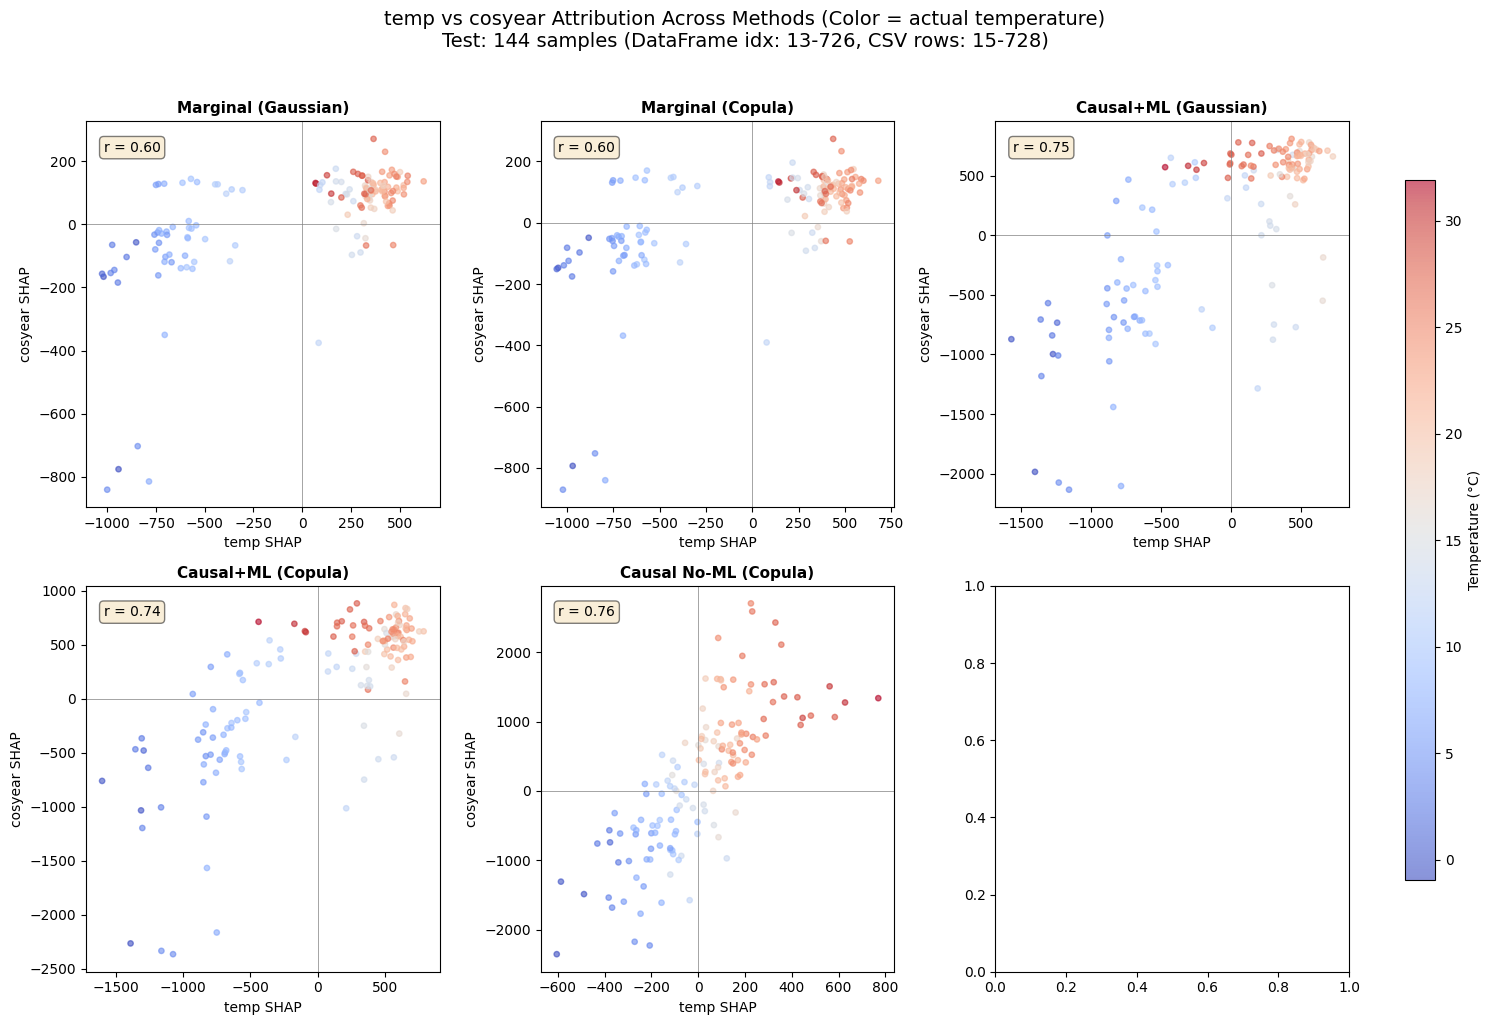

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

temp_idx = feature_names.index('temp')
cosyear_idx = feature_names.index('cosyear')
temp_values = X_test[:, temp_idx]

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    scatter = ax.scatter(
        sv[:, temp_idx], 
        sv[:, cosyear_idx], 
        c=temp_values,
        cmap='coolwarm', 
        s=15, 
        alpha=0.6
    )
    
    ax.set_xlabel('temp SHAP')
    ax.set_ylabel('cosyear SHAP')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(exp_name, fontsize=11, fontweight='bold')
    
    corr = np.corrcoef(sv[:, temp_idx], sv[:, cosyear_idx])[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)')

test_csv_rows = test_idx + 2
plt.suptitle(f'temp vs cosyear Attribution Across Methods (Color = actual temperature)\n'
             f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()


## 14. Grouped Bar Chart: Marginal vs Causal Methods

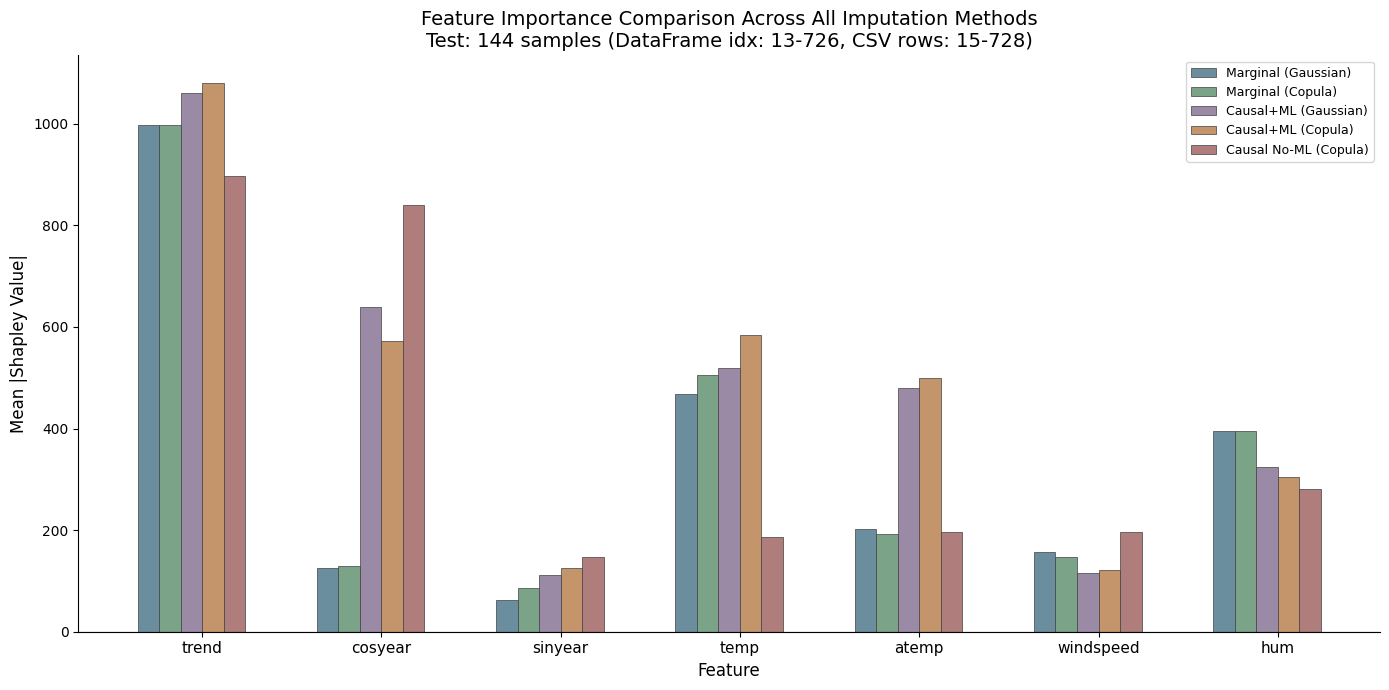

In [16]:
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(feature_names))
width = 0.12
multiplier = 0

# colors
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#7BA388',  # Muted sage green (Marginal Gaussian)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#C4956A',  # Muted terracotta (Causal Gaussian) ★
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-ML)
]

for i, (exp_name, sv) in enumerate(all_sv.items()):
    importance = np.abs(sv).mean(axis=0)
    offset = width * multiplier
    bars = ax.bar(x + offset, importance, width, label=exp_name, color=colors[i], edgecolor='#404040', linewidth=0.5)
    multiplier += 1

ax.set_ylabel('Mean |Shapley Value|', fontsize=12)
ax.set_xlabel('Feature', fontsize=12)
test_csv_rows = test_idx + 2
ax.set_title(f'Feature Importance Comparison Across All Imputation Methods\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(feature_names, fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 15. Correlation Matrix Between Methods

How similar are the Shapley values from different methods?

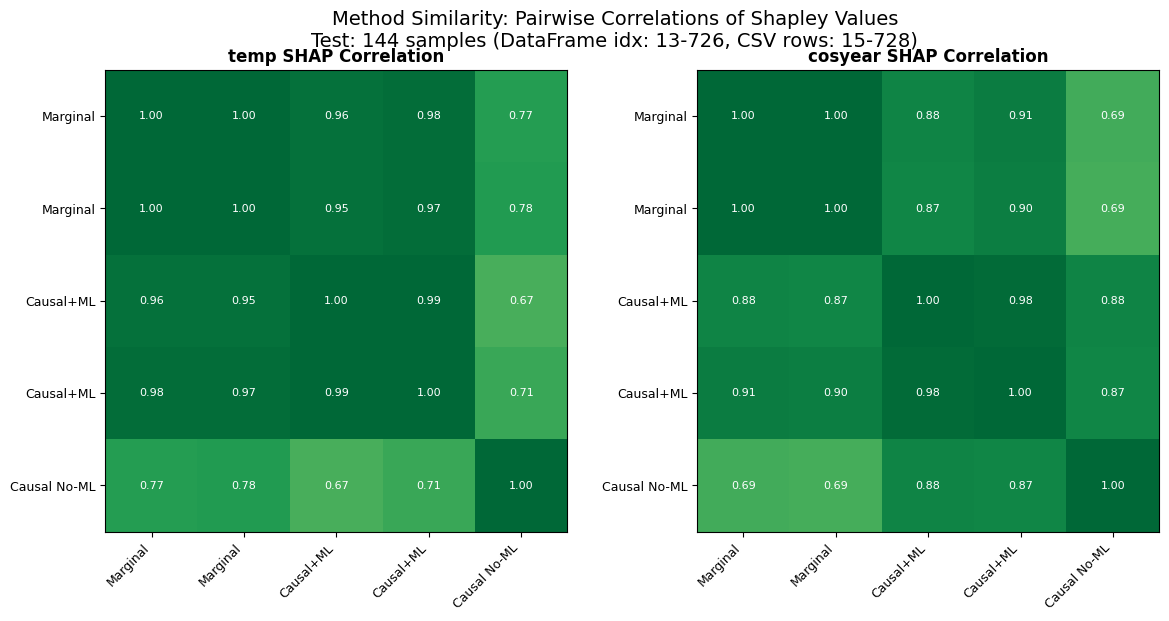

In [17]:
methods = list(all_sv.keys())
n_methods = len(methods)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (feat_name, feat_idx) in enumerate([('temp', temp_idx), ('cosyear', cosyear_idx)]):
    corr_matrix = np.zeros((n_methods, n_methods))
    
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            corr_matrix[i, j] = np.corrcoef(
                all_sv[m1][:, feat_idx], 
                all_sv[m2][:, feat_idx]
            )[0, 1]
    
    ax = axes[ax_idx]
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
    
    ax.set_xticks(range(n_methods))
    ax.set_xticklabels([m.split('(')[0].strip() for m in methods], rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n_methods))
    ax.set_yticklabels([m.split('(')[0].strip() for m in methods], fontsize=9)
    
    for i in range(n_methods):
        for j in range(n_methods):
            color = 'white' if abs(corr_matrix[i, j]) > 0.5 else 'black'
            ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', 
                   color=color, fontsize=8)
    
    ax.set_title(f'{feat_name} SHAP Correlation', fontsize=12, fontweight='bold')

test_csv_rows = test_idx + 2
plt.suptitle(f'Method Similarity: Pairwise Correlations of Shapley Values\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, y=0.98)
plt.show()


## 16. Distribution Comparison: Marginal vs Causal Groups

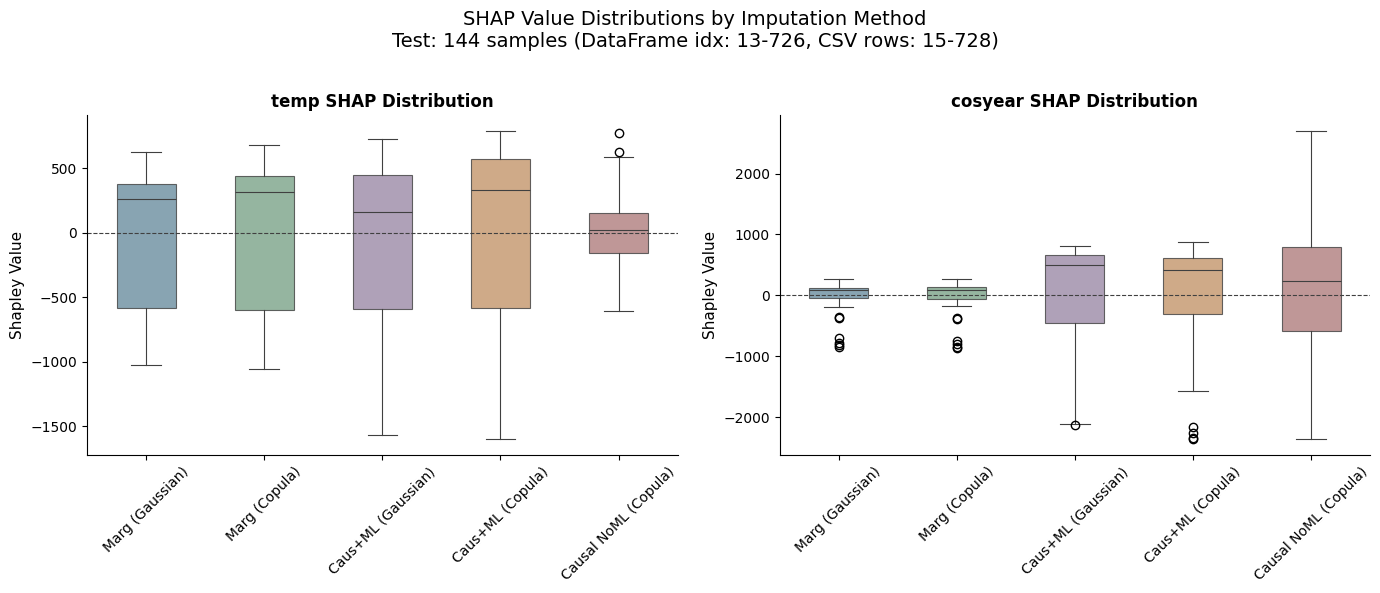

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# colors
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#7BA388',  # Muted sage green (Marginal Gaussian)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#C4956A',  # Muted terracotta (Causal Gaussian) ★
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-ML)
]

for ax_idx, (feat_name, feat_idx) in enumerate([('temp', temp_idx), ('cosyear', cosyear_idx)]):
    ax = axes[ax_idx]
    
    data_to_plot = [all_sv[m][:, feat_idx] for m in methods]
    short_names = [m.replace('Marginal', 'Marg').replace('Causal+ML', 'Caus+ML').replace('No-ML', 'NoML') 
                   for m in methods]
    
    bp = ax.boxplot(data_to_plot, labels=short_names, patch_artist=True)
    
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i])
        patch.set_edgecolor('#404040')
        patch.set_linewidth(0.8)
        patch.set_alpha(0.8)
    
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('#404040')
            item.set_linewidth(0.8)
    
    ax.axhline(y=0, color='#404040', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Shapley Value', fontsize=11)
    ax.set_title(f'{feat_name} SHAP Distribution', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

test_csv_rows = test_idx + 2
plt.suptitle(f'SHAP Value Distributions by Imputation Method\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 17. Summary Table and Key Insights

               Method  |temp| mean  |cosyear| mean  cosyear/temp ratio  Category
  Marginal (Gaussian)   467.031329      125.558061            0.268843  Marginal
    Marginal (Copula)   505.463281      130.002519            0.257195  Marginal
 Causal+ML (Gaussian)   519.121080      639.946884            1.232751 Causal+ML
   Causal+ML (Copula)   584.004296      572.597456            0.980468 Causal+ML
Causal No-ML (Copula)   186.379280      839.362603            4.503519     No-ML


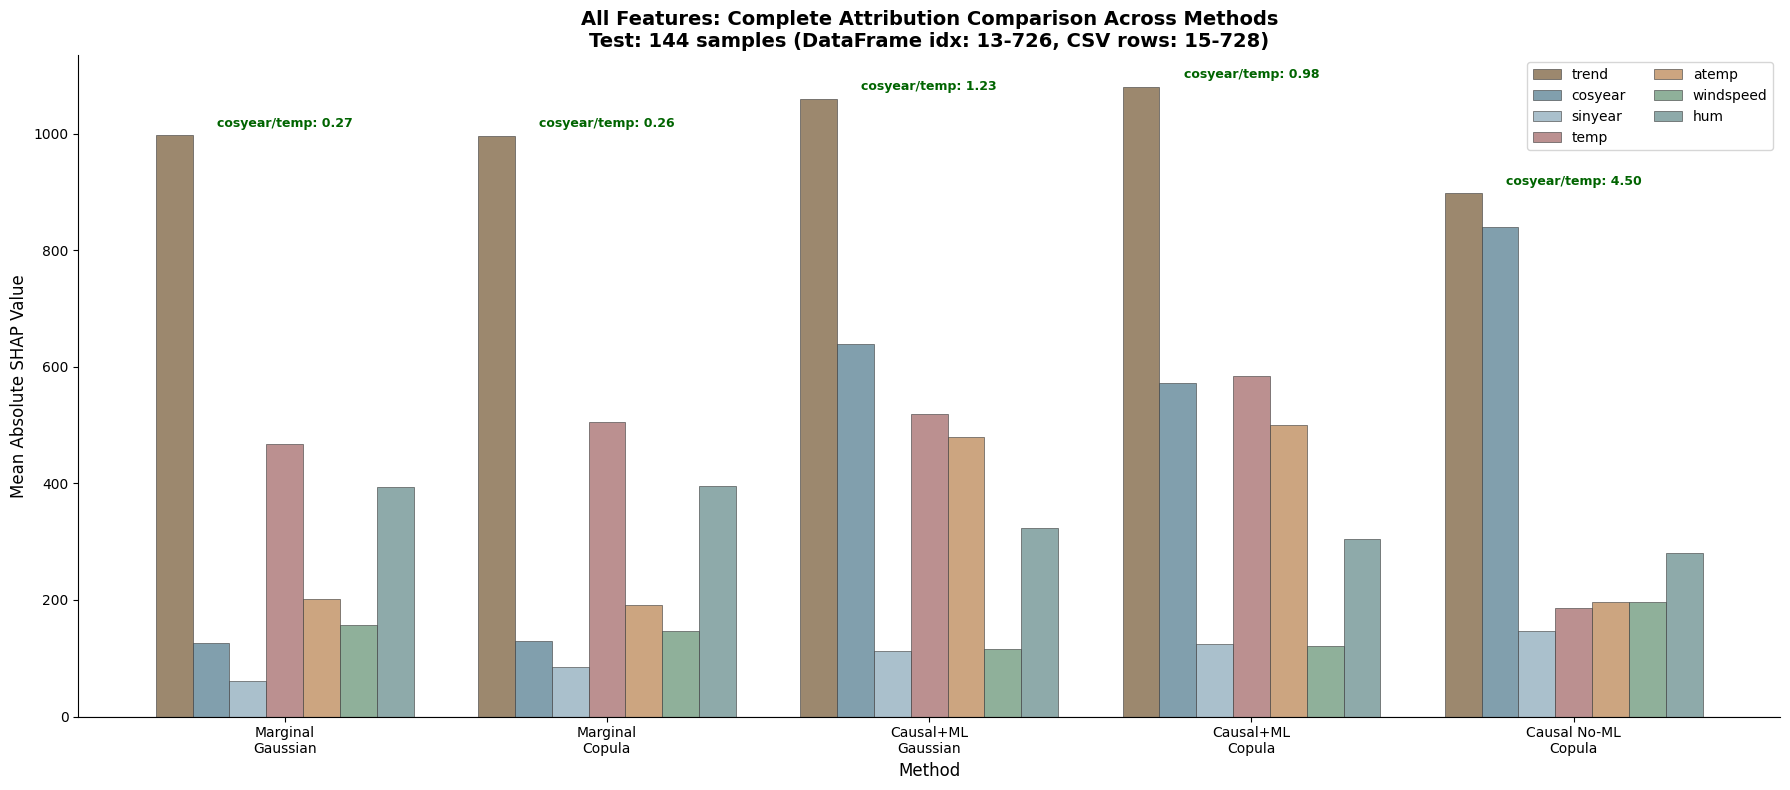

In [19]:
test_csv_rows = test_idx + 2

summary_data = []
for exp_name, sv in all_sv.items():
    temp_mean = np.abs(sv[:, temp_idx]).mean()
    cosyear_mean = np.abs(sv[:, cosyear_idx]).mean()
    ratio = cosyear_mean / temp_mean if temp_mean > 0 else 0
    
    summary_data.append({
        'Method': exp_name,
        '|temp| mean': temp_mean,
        '|cosyear| mean': cosyear_mean,
        'cosyear/temp ratio': ratio,
        'Category': 'Marginal' if 'Marginal' in exp_name else ('No-ML' if 'No-ML' in exp_name else 'Causal+ML')
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(18, 8))

x = np.arange(len(summary_df))
n_features = len(feature_names)
width = 0.8 / n_features
multiplier = 0

# colors
feature_colors = {
    'trend': '#8B7355',      # Muted brown
    'cosyear': '#6B8E9F',    # Muted steel blue
    'sinyear': '#9BB5C4',    # Muted sky blue
    'temp': '#B07D7D',       # Muted rose
    'atemp': '#C4956A',      # Muted terracotta
    'windspeed': '#7BA388',  # Muted sage green
    'hum': '#7A9B9B'         # Muted teal
}

for feat_name in feature_names:
    feat_idx = feature_names.index(feat_name)
    values = [np.abs(all_sv[exp_name][:, feat_idx]).mean() for exp_name in all_sv.keys()]
    offset = width * multiplier - width * (n_features - 1) / 2
    bars = ax.bar(x + offset, values, width, label=feat_name, 
                 color=feature_colors[feat_name], edgecolor='#404040', linewidth=0.5, alpha=0.85)
    multiplier += 1

ax.set_ylabel('Mean Absolute SHAP Value', fontsize=12)
ax.set_xlabel('Method', fontsize=12)
ax.set_title(f'All Features: Complete Attribution Comparison Across Methods\n'
            f'Test: {len(test_idx)} samples (DataFrame idx: {test_idx[0]}-{test_idx[-1]}, CSV rows: {test_csv_rows[0]}-{test_csv_rows[-1]})', 
            fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.split('(')[0].strip() + '\n' + (m.split('(')[1].replace(')', '') if '(' in m else '') 
                    for m in summary_df['Method']], fontsize=10)
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, row in summary_df.iterrows():
    max_val = max([np.abs(all_sv[row['Method']][:, feature_names.index(f)]).mean() for f in feature_names])
    ax.annotate(f"cosyear/temp: {row['cosyear/temp ratio']:.2f}", 
                xy=(i, max_val + 15),
                ha='center', fontsize=9, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()


## 18. k-SII Network Graph Comparison

> **Note**: This section visualizes **k-Shapley Interaction Index (k-SII)** as network graphs for different imputation methods. 
> 
> **Important**: The k-SII values (max_order=2) were already computed in Section 5, so we directly reuse those results here. The network graphs show:
> - **Nodes**: Features (size proportional to main effect / 1st-order Shapley value)
> - **Edges**: Pairwise interactions (width/color proportional to 2nd-order interaction strength)
>
> This comparison reveals how causal structure affects not just individual attributions, but also **feature interactions**.

In [20]:
sample_idx = len(X_test) // 2  # middle test sample
x_sample = X_test[sample_idx:sample_idx+1]

print(f"Selected test sample index: {sample_idx}")
print(f"Sample features:")
for i, fname in enumerate(feature_names):
    print(f"  {fname}: {x_sample[0, i]:.2f}")

ksii_results = {}
for exp_name in all_ksii.keys():
    ksii_results[exp_name] = all_ksii[exp_name][sample_idx]
    print(f"  {exp_name}: Retrieved (interactions: {len(ksii_results[exp_name])})")


Selected test sample index: 72
Sample features:
  trend: 351.00
  cosyear: 0.97
  sinyear: -0.24
  temp: 3.20
  atemp: 0.21
  windspeed: 11.38
  hum: 58.63
  Marginal (Gaussian): Retrieved (interactions: 29)
  Marginal (Copula): Retrieved (interactions: 29)
  Causal+ML (Gaussian): Retrieved (interactions: 29)
  Causal+ML (Copula): Retrieved (interactions: 29)
  Causal No-ML (Copula): Retrieved (interactions: 29)


k-SII Network Graphs — sample: Test idx 72 (DataFrame idx: 351, CSV row: 353)

k-SII Network: Marginal (Gaussian) [Paper MSV]


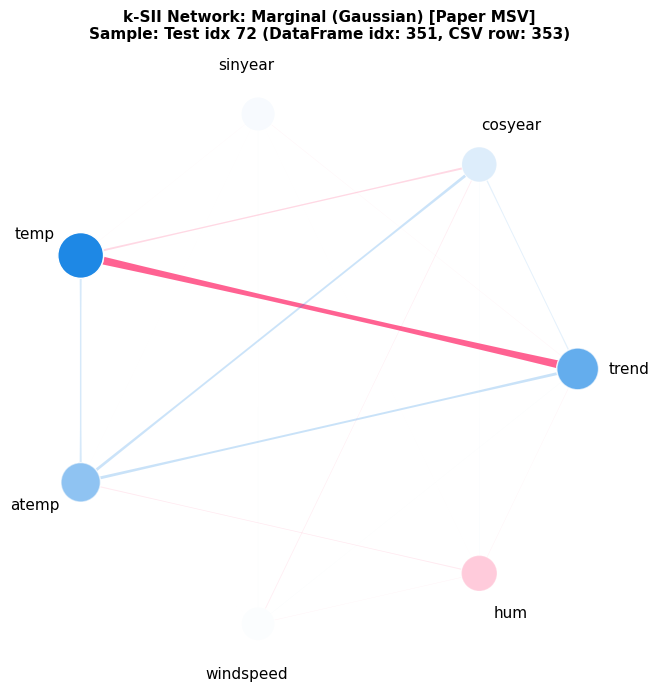


k-SII Network: Marginal (Copula)


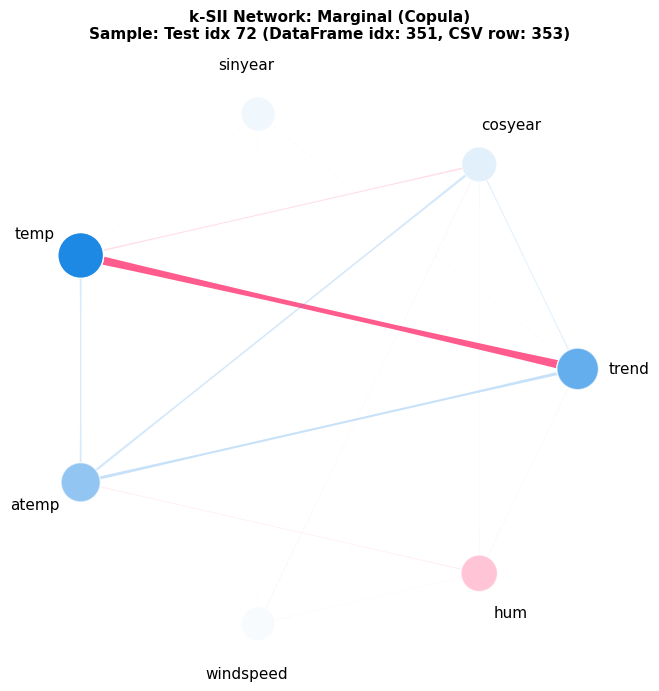


k-SII Network: Causal+ML (Gaussian) [Paper CSV]


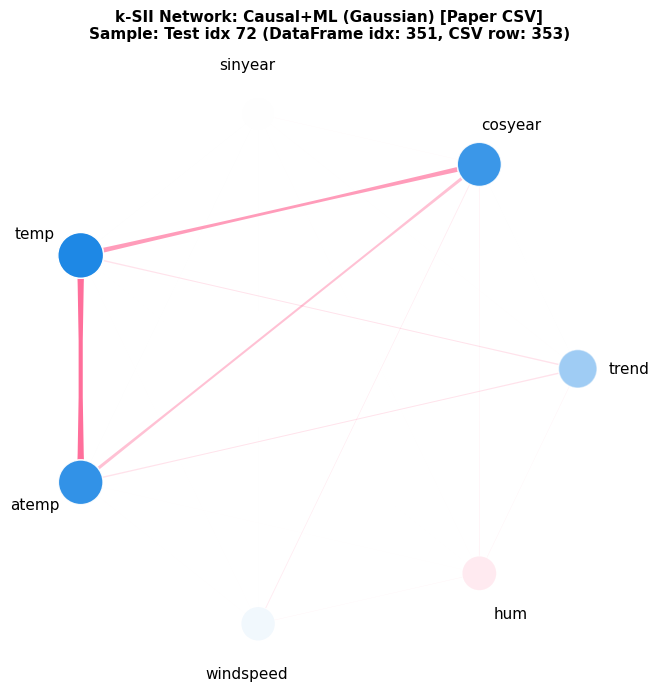


k-SII Network: Causal+ML (Copula)


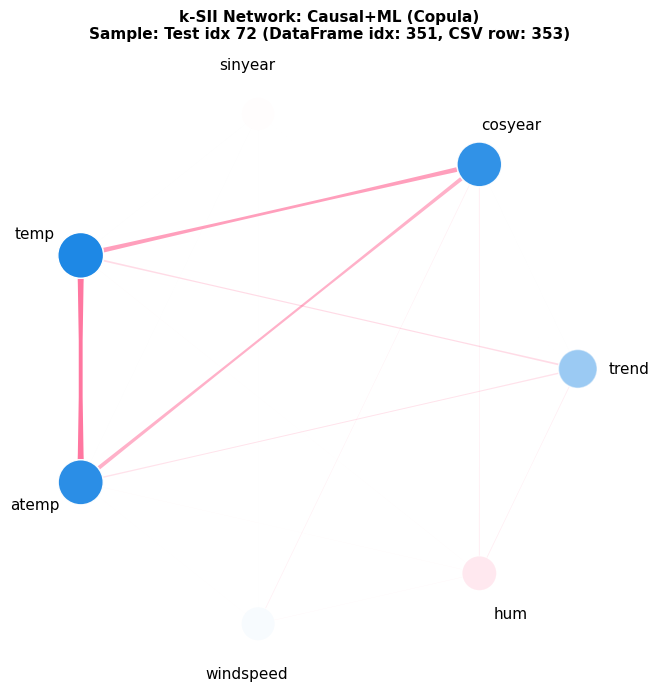


k-SII Network: Causal No-ML (Copula)


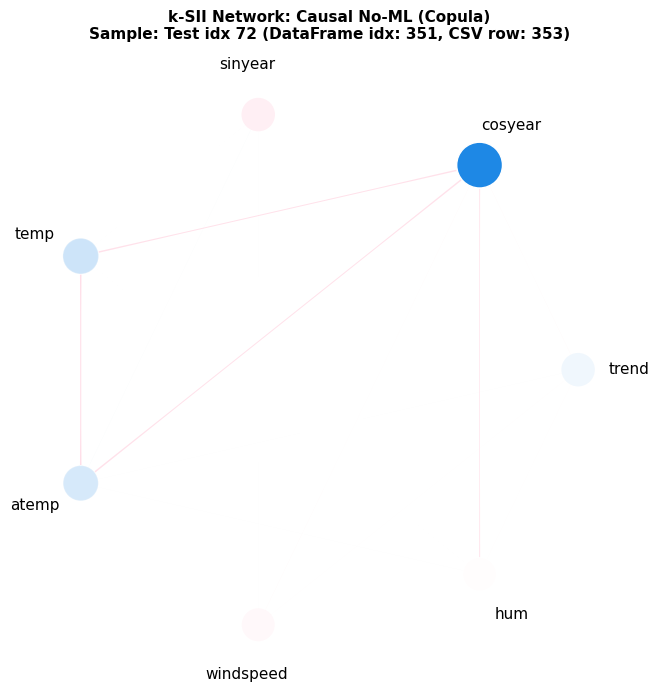

In [21]:
test_csv_row = test_idx[sample_idx] + 2

print(f"k-SII Network Graphs — sample: Test idx {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")

for exp_name, result in ksii_results.items():
    title = f"k-SII Network: {exp_name}"
    if exp_name == 'Marginal (Gaussian)':
        title += ' [Paper MSV]'
    elif exp_name == 'Causal+ML (Gaussian)':
        title += ' [Paper CSV]'
    
    print(f"\n{title}")
    
    fig, ax = result.plot_network(feature_names=feature_names, show=False)
    fig.suptitle(f"{title}\nSample: Test idx {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})", 
                fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [22]:
test_csv_row = test_idx[sample_idx] + 2
print("k-SII INTERACTION VALUES COMPARISON")
print(f"Sample: Test index {sample_idx} (DataFrame idx: {test_idx[sample_idx]}, CSV row: {test_csv_row})")

# Key feature pairs to compare
key_pairs = [
    (feature_names.index('temp'), feature_names.index('cosyear')),
    (feature_names.index('temp'), feature_names.index('atemp')),
    (feature_names.index('cosyear'), feature_names.index('sinyear')),
    (feature_names.index('temp'), feature_names.index('hum')),
    (feature_names.index('trend'), feature_names.index('cosyear')),
]

print("\n" + "-"*90)
print(f"{'Feature Pair':<25} ", end="")
for exp_name in ksii_results.keys():
    short_name = exp_name.split('(')[0].strip()[:8]
    print(f"{short_name:>10}", end="")
print()
print("-"*90)

for i, j in key_pairs:
    pair_name = f"({feature_names[i]}, {feature_names[j]})"
    print(f"{pair_name:<25} ", end="")
    for exp_name, result in ksii_results.items():
        try:
            interaction_val = result[(i, j)]
        except (KeyError, IndexError):
            try:
                interaction_val = result[(j, i)]
            except (KeyError, IndexError):
                interaction_val = 0.0
        print(f"{interaction_val:>10.3f}", end="")
    print()

print("\n" + "-"*90)
print("1st-order (Main Effects):")
print("-"*90)
print(f"{'Feature':<25} ", end="")
for exp_name in ksii_results.keys():
    short_name = exp_name.split('(')[0].strip()[:8]
    print(f"{short_name:>10}", end="")
print()
print("-"*90)

for i, fname in enumerate(feature_names):
    print(f"{fname:<25} ", end="")
    for exp_name, result in ksii_results.items():
        try:
            main_effect = result[(i,)]
        except (KeyError, IndexError):
            main_effect = 0.0
        print(f"{main_effect:>10.3f}", end="")
    print()


k-SII INTERACTION VALUES COMPARISON
Sample: Test index 72 (DataFrame idx: 351, CSV row: 353)

------------------------------------------------------------------------------------------
Feature Pair                Marginal  Marginal  Causal+M  Causal+M  Causal N
------------------------------------------------------------------------------------------
(temp, cosyear)              155.717   131.604   550.009   517.153   204.808
(temp, atemp)               -174.702  -172.742   807.921   730.231   220.997
(cosyear, sinyear)            -9.390    -6.704    41.270    16.272    18.134
(temp, hum)                    1.662    -1.262    17.602    29.783   -19.463
(trend, cosyear)            -112.127  -121.992   -22.577   -25.796    44.710

------------------------------------------------------------------------------------------
1st-order (Main Effects):
------------------------------------------------------------------------------------------
Feature                     Marginal  Marginal  Causa

In [23]:
from shapiq.interaction_values import aggregate_interaction_values

n_samples_ksii = 10
sample_indices = np.linspace(0, len(X_test)-1, n_samples_ksii, dtype=int)

agg_test_csv_rows = test_idx[sample_indices] + 2
print(f"Aggregating {n_samples_ksii} samples: DataFrame idx {test_idx[sample_indices].tolist()}")

agg_ksii_results = {}

for exp_name in all_ksii.keys():
    results_list = [all_ksii[exp_name][i] for i in sample_indices]
    agg_ksii_results[exp_name] = aggregate_interaction_values(results_list)
    print(f"  {exp_name}: done ({len(results_list)} samples)")

print("\nAggregation complete.")


Aggregating 10 samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]
  Marginal (Gaussian): done (10 samples)
  Marginal (Copula): done (10 samples)
  Causal+ML (Gaussian): done (10 samples)
  Causal+ML (Copula): done (10 samples)
  Causal No-ML (Copula): done (10 samples)

Aggregation complete.


Aggregated k-SII Network Graphs (average over 10 test samples):
Samples: DataFrame idx [13, 91, 147, 207, 271, 395, 477, 563, 654, 726]

Aggregated k-SII Network: Marginal (Gaussian) ★[Paper MSV]


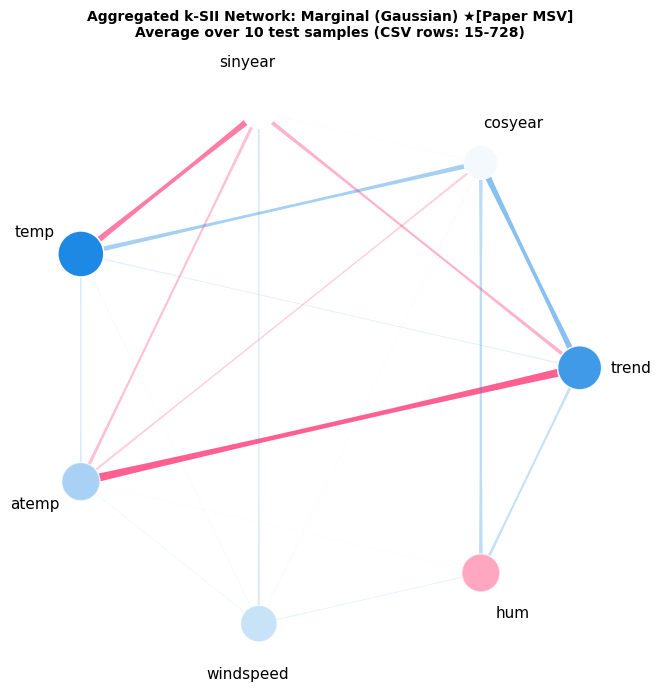


Aggregated k-SII Network: Marginal (Copula)


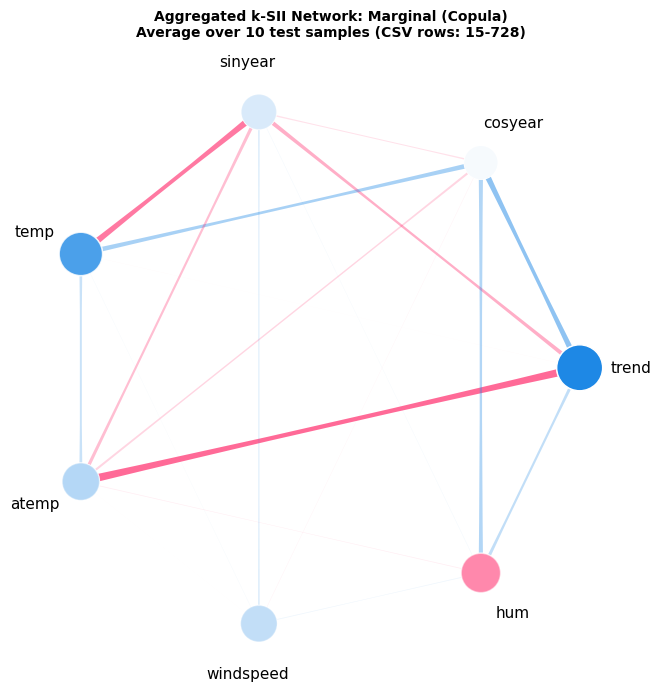


Aggregated k-SII Network: Causal+ML (Gaussian) ★[Paper CSV]


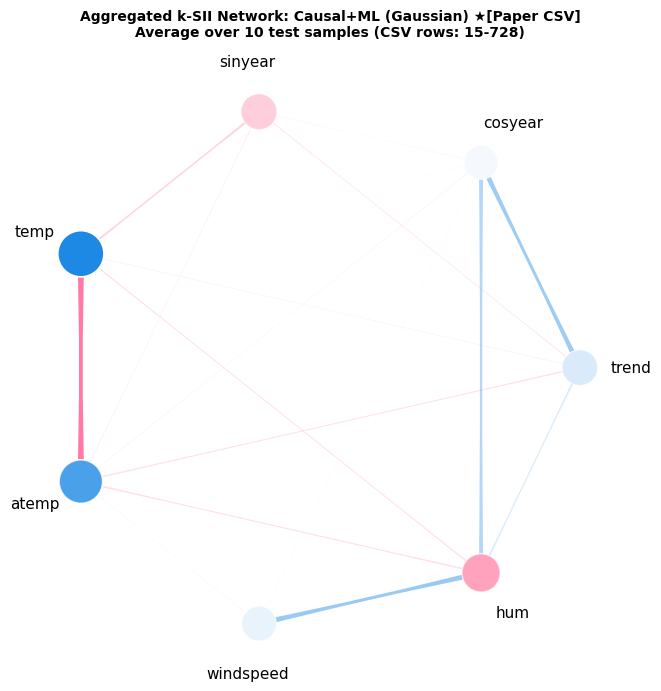


Aggregated k-SII Network: Causal+ML (Copula)


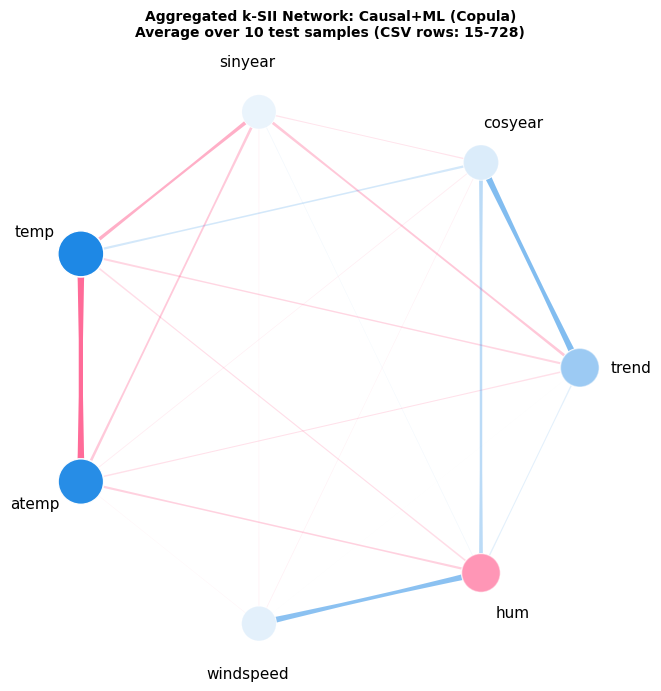


Aggregated k-SII Network: Causal No-ML (Copula)


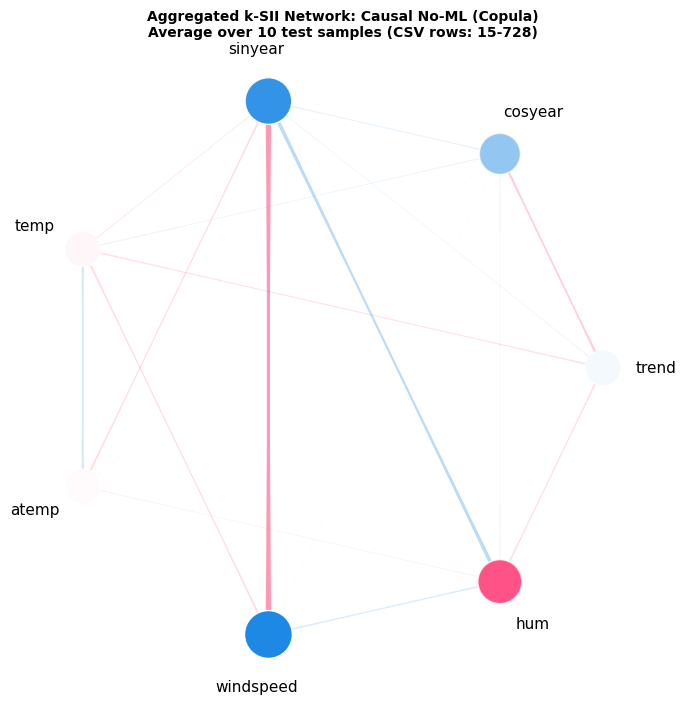

In [24]:
print(f"Aggregated k-SII Network Graphs (average over {n_samples_ksii} test samples):")
print(f"Samples: DataFrame idx {test_idx[sample_indices].tolist()}")

for exp_name, agg_result in agg_ksii_results.items():
    title = f"Aggregated k-SII Network: {exp_name}"
    if exp_name == 'Marginal (Gaussian)':
        title += ' ★[Paper MSV]'
    elif exp_name == 'Causal+ML (Gaussian)':
        title += ' ★[Paper CSV]'
    
    print(f"\n{title}")
    
    fig, ax = agg_result.plot_network(feature_names=feature_names, show=False)
    fig.suptitle(f"{title}\nAverage over {n_samples_ksii} test samples (CSV rows: {(test_idx[sample_indices] + 2)[0]}-{(test_idx[sample_indices] + 2)[-1]})", 
                fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()


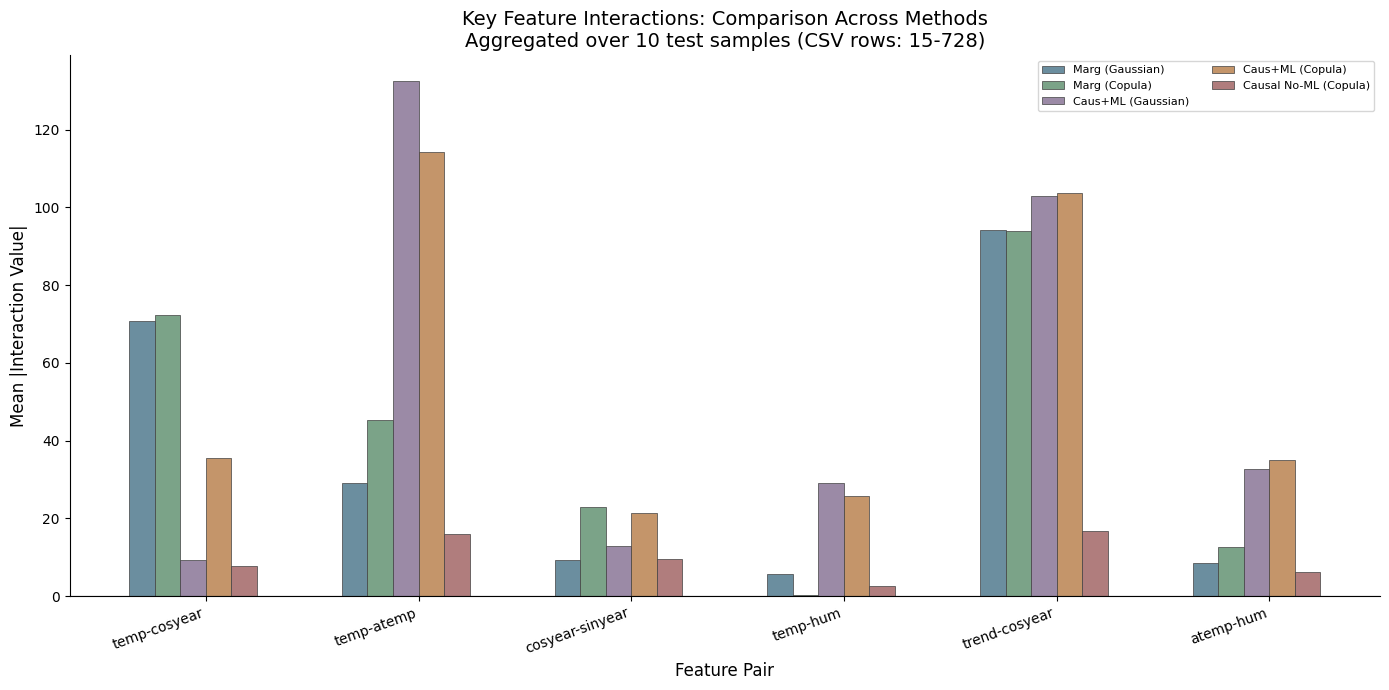

In [25]:
fig, ax = plt.subplots(figsize=(14, 7))

key_pairs_names = [
    ('temp', 'cosyear'),
    ('temp', 'atemp'),
    ('cosyear', 'sinyear'),
    ('temp', 'hum'),
    ('trend', 'cosyear'),
    ('atemp', 'hum'),
]

x = np.arange(len(key_pairs_names))
width = 0.12
multiplier = 0

# colors
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal Joint)
    '#7BA388',  # Muted sage green (Marginal Gaussian)
    '#9B8AA6',  # Muted lavender (Marginal Copula)
    '#C4956A',  # Muted terracotta (Causal Gaussian) ★
    '#B07D7D',  # Muted rose (Causal Copula)
    '#8B8B7A',  # Muted olive (No-ML)
]

for color_idx, (exp_name, agg_result) in enumerate(agg_ksii_results.items()):
    values = []
    for f1, f2 in key_pairs_names:
        i, j = feature_names.index(f1), feature_names.index(f2)
        try:
            interaction_val = abs(agg_result[(i, j)])
        except (KeyError, IndexError):
            try:
                interaction_val = abs(agg_result[(j, i)])
            except (KeyError, IndexError):
                interaction_val = 0.0
        values.append(interaction_val)
    
    offset = width * multiplier
    short_name = exp_name.replace('Marginal', 'Marg').replace('Causal+ML', 'Caus+ML')
    bars = ax.bar(x + offset, values, width, label=short_name, 
                 color=colors[color_idx], edgecolor='#404040', linewidth=0.5)
    multiplier += 1

ax.set_ylabel('Mean |Interaction Value|', fontsize=12)
ax.set_xlabel('Feature Pair', fontsize=12)
ax.set_title(f'Key Feature Interactions: Comparison Across Methods\n'
            f'Aggregated over {n_samples_ksii} test samples (CSV rows: {(test_idx[sample_indices] + 2)[0]}-{(test_idx[sample_indices] + 2)[-1]})', 
            fontsize=14)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels([f'{f1}-{f2}' for f1, f2 in key_pairs_names], fontsize=10, rotation=20, ha='right')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Conclusion

This notebook reproduced the core analysis from Heskes et al. (2020) using **k-SII (max_order=2)** and compared **Marginal Shapley Values (MSV)** with **Causal Shapley Values (CSV)** across 5 imputation methods on the UCI Bike Sharing dataset. Below is a summary of key observations from some sections.

### Comprehensive Imputer Comparison (Section 17)

1. **Marginal Methods** (Gaussian, Copula): Assign high importance to `temp` directly; lower attribution to `cosyear`. The cosyear/temp ratio < 1.
2. **Causal+ML Methods** (Gaussian, Copula): Shift attribution from `temp` to `cosyear` (root cause). Higher cosyear/temp ratio. Copula is typically more robust than Gaussian for non-normal data.
3. **Causal No-ML Method**: Uses a linear conditional Gaussian model for Y (different from XGBoost). Shows how causal structure affects attribution even without a ml model.
4. **Gaussian vs Copula**: Gaussian assumes multivariate normal; Copula preserves marginal distributions and captures dependencies. For non-Gaussian data like bike rentals, Copula is generally preferred.

---

### k-SII Network Graphs (Section 18)

2. **Edge Thickness (Interactions)**: Marginal methods show strong `temp`–`cosyear` interaction (spurious correlation). 
3. **Network Structure**: Marginal methods produce dense connections (correlations treated as interactions); causal methods produce sparser, more interpretable networks where only genuine causal interactions remain.
4. **Key Finding**: The `temp`–`cosyear` interaction pattern differs fundamentally between methods. Marginal methods treat correlation as interaction, while causal methods correctly model the dependency structure (trend → season → weather), preserving only some interactions (e.g., `temp`–`atemp`, `temp`–`hum`).


### References

1. **Causal Shapley Values (reproduced paper)**: Heskes, T., Bucur, I. G., Sijben, E., & Claassen, T. (2020). *Causal Shapley Values: Exploiting Causal Knowledge to Explain Individual Predictions of Complex Models*. Advances in Neural Information Processing Systems (NeurIPS), 33. [arXiv:2011.01625](https://arxiv.org/abs/2011.01625)

3. **k-SII & SHAP-IQ**: Fumagalli, F., Muschalik, M., Kolpaczki, P., Hüllermeier, E., & Hammer, B. (2024). *SHAP-IQ: Unified Estimation of any-order Shapley Interactions*. Advances in Neural Information Processing Systems (NeurIPS), 37.
